# King County Housing Market — Exploratory Data Analysis

## Project goal

This project explores residential property sales in King County, Washington, for a fictional client, **Nicole Johnson**.

Nicole is looking for:
- a lively, relatively central neighbourhood
- a home in the middle of the market
- a purchase within the coming year

The analysis focuses on three questions:
1. **Timing:** Are homes cheaper in some seasons?
2. **Centrality:** How does typical price change with distance from central Seattle?
3. **Living space:** Within the middle-price range, does moving farther out provide more living space?

The final goal is to narrow the market to a small set of ZIP codes that deserve closer investigation.

## 1. Setup

Import the libraries used for data preparation, analysis, visualisation, and external population-density data.

In [1]:
import os
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False
})

## 2. Load the housing dataset

The joined housing data is loaded from `data/eda.csv`.

In [2]:
# Load the joined housing dataset from the CSV file

df = pd.read_csv("data/eda.csv")

## 3. Dataset overview

Before cleaning or analysis, inspect the first rows, dataset size, data types, missing values, and numerical summary.

In [3]:
# Show the first five rows to get a first impression of the dataset

df.head()

,sale_id,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,2014-10-13,221900.0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2,2014-12-09,538000.0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,3,2015-02-25,180000.0,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,4,2014-12-09,604000.0,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,5,2015-02-18,510000.0,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique ZIP codes: {df['zipcode'].nunique()}")

df.info()

Rows: 21,597
Columns: 22
Unique ZIP codes: 70
<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   id             21597 non-null  int64  
 4   bedrooms       21597 non-null  float64
 5   bathrooms      21597 non-null  float64
 6   sqft_living    21597 non-null  float64
 7   sqft_lot       21597 non-null  float64
 8   floors         21597 non-null  float64
 9   waterfront     19206 non-null  float64
 10  view           21534 non-null  float64
 11  condition      21597 non-null  int64  
 12  grade          21597 non-null  int64  
 13  sqft_above     21597 non-null  float64
 14  sqft_basement  21145 non-null  float64
 15  yr_built       21597 non-null  int64  
 16  yr_renovated   17749 non-null  float64
 17  zipcode        

In [5]:
missing = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing[missing["missing_values"] > 0]

,missing_values,missing_percent
waterfront,2391,11.07
view,63,0.29
sqft_basement,452,2.09
yr_renovated,3848,17.82


In [6]:
# Display descriptive statistics for the numerical columns
df.describe()

,sale_id,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.000000,2.159700e+04,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,21534.000000,...,21597.000000,21597.000000,21145.000000,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,10799.000000,5.402966e+05,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,0.233863,...,7.657915,1788.596842,291.857224,1970.999676,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512
std,6234.661218,3.673681e+05,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,0.765686,...,1.173200,827.759761,442.490863,29.375234,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950
min,1.000000,7.800000e+04,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,...,3.000000,370.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5400.000000,3.220000e+05,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,10799.000000,4.500000e+05,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,16198.000000,6.450000e+05,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21597.000000,7.700000e+06,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Initial observations

- **21,597 sales**
- **22 original variables**
- **70 ZIP codes**
- Median sale price: about **$450,000**
- Middle 50% of prices: approximately **$322,000–$645,000**
- Price is right-skewed, with a small number of very expensive properties.
- Missing values are concentrated in `waterfront`, `view`, `sqft_basement`, and `yr_renovated`.

## 4. Data cleaning

Before drawing conclusions, check for exact duplicate rows, data types, missing-value meaning, and suspicious or extreme values.

Repeated property IDs are not automatically duplicates because the same property can be sold more than once.

In [7]:
#Cleaning

# Check for exact duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.rename(columns={"id": "house_id"})
df["zipcode"] = df["zipcode"].astype(str)
df["bedrooms"] = df["bedrooms"].astype(int)
df["date"] = pd.to_datetime(df["date"])

In [9]:
for column in ["waterfront", "view", "sqft_basement", "yr_renovated"]:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(10))


waterfront
waterfront
0.0    19060
NaN     2391
1.0      146
Name: count, dtype: int64

view
view
0.0    19422
2.0      957
3.0      508
1.0      330
4.0      317
NaN       63
Name: count, dtype: int64

sqft_basement
sqft_basement
0.0       12827
NaN         452
600.0       217
700.0       209
500.0       209
800.0       201
400.0       184
1000.0      148
300.0       142
900.0       142
Name: count, dtype: int64

yr_renovated
yr_renovated
0.0        17005
NaN         3848
20140.0       73
20130.0       31
20030.0       31
20070.0       30
20050.0       29
20000.0       29
19900.0       22
20040.0       22
Name: count, dtype: int64


### Cleaning decisions

- No exact duplicate rows were found.
- The property identifier was renamed to `house_id`.
- ZIP codes are treated as categorical values.
- Sale dates are converted to datetime.
- Missing values remain `NaN`; replacing them with zero could change their meaning because zero is already valid in these fields.
- Extreme prices and living-space values were inspected rather than automatically removed.

In [10]:
print("Most expensive sales")
display(df.nlargest(10, "price")[["price", "sqft_living", "bedrooms", "bathrooms", "grade", "zipcode"]])

print("Largest homes")
display(df.nlargest(10, "sqft_living")[["price", "sqft_living", "bedrooms", "bathrooms", "grade", "zipcode"]])

Most expensive sales


,price,sqft_living,bedrooms,bathrooms,grade,zipcode
7245,7700000.0,12050.0,6,8.00,13,98102
3910,7060000.0,10040.0,5,4.50,11,98004
9245,6890000.0,9890.0,6,7.75,13,98039
4407,5570000.0,9200.0,5,5.75,13,98039
1446,5350000.0,8000.0,5,5.00,12,98004
1313,5300000.0,7390.0,6,6.00,12,98040
1162,5110000.0,8010.0,5,5.25,12,98033
8085,4670000.0,9640.0,5,6.75,12,98040
2624,4500000.0,6640.0,5,5.50,12,98155
8629,4490000.0,6430.0,4,3.00,12,98004


Largest homes


,price,sqft_living,bedrooms,bathrooms,grade,zipcode
12764,2280000.0,13540.0,7,8.00,12,98053
7245,7700000.0,12050.0,6,8.00,13,98102
3910,7060000.0,10040.0,5,4.50,11,98004
9245,6890000.0,9890.0,6,7.75,13,98039
8085,4670000.0,9640.0,5,6.75,12,98040
4407,5570000.0,9200.0,5,5.75,13,98039
14542,2890000.0,8670.0,5,6.25,13,98177
18288,3300000.0,8020.0,5,6.25,11,98006
1162,5110000.0,8010.0,5,5.25,12,98033
1446,5350000.0,8000.0,5,5.00,12,98004


## 5. Feature engineering

Create the derived variables required for the client questions:
- season
- straight-line distance from central Seattle
- fixed distance bands
- population density
- middle-price range

In [11]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Fall"

df["season"] = df["month"].apply(get_season)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Date range: 2014-05-02 to 2015-05-27


### 5.1 Distance from central Seattle

Use approximately **47.61, -122.33** as a central Seattle reference point.

Distance is calculated with the Haversine formula and represents **straight-line geographic distance**, not driving distance or commute time.

In [12]:
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

seattle_lat = 47.61
seattle_long = -122.33

df["distance_km"] = haversine_km(
    seattle_lat,
    seattle_long,
    df["lat"],
    df["long"]
)

df["distance_km"].describe()

count    21597.000000
mean        18.437749
std         10.741277
min          0.947705
25%          9.681401
50%         16.361892
75%         25.246384
max         76.871579
Name: distance_km, dtype: float64

In [13]:
distance_bins = [0, 5, 10, 15, 20, 30, 50, float("inf")]

distance_labels = [
    "0–5 km", "5–10 km", "10–15 km", "15–20 km",
    "20–30 km", "30–50 km", "50+ km"
]

df["distance_band"] = pd.cut(
    df["distance_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True,
    right=False
)

df["distance_band"].value_counts().sort_index()

distance_band
0–5 km      1345
5–10 km     4399
10–15 km    3801
15–20 km    3857
20–30 km    4372
30–50 km    3621
50+ km       202
Name: count, dtype: int64

### 5.2 Population density

The housing data does not directly measure neighbourhood liveliness.

Population density is added as a **supporting proxy for urban character**. It should not be interpreted as a direct measure of nightlife, amenities, walkability, or neighbourhood quality.

In [14]:
population_raw = pd.read_csv("data/B01003.csv.gz")

with zipfile.ZipFile("data/2015_Gaz_zcta_national.zip") as z:
    filename = z.namelist()[0]
    with z.open(filename) as f:
        land_raw = pd.read_csv(f, sep="\t")

print("Population data:", population_raw.shape)
print("Land-area data:", land_raw.shape)

Population data: (33122, 89)
Land-area data: (33144, 7)


In [15]:
population_clean = population_raw[population_raw["GEOID"].notna()].copy()
population_clean["zipcode"] = population_clean["GEOID"].str[-5:]
population_clean = population_clean.rename(columns={"estimate": "population"})
population_clean = population_clean[["zipcode", "population"]]

land_clean = land_raw[["GEOID", "ALAND"]].copy()
land_clean = land_clean.rename(columns={"GEOID": "zipcode", "ALAND": "land_area_m2"})
land_clean["zipcode"] = land_clean["zipcode"].astype(str).str.zfill(5)
land_clean["land_area_km2"] = land_clean["land_area_m2"] / 1_000_000

density_df = population_clean.merge(
    land_clean[["zipcode", "land_area_km2"]],
    on="zipcode",
    how="inner"
)

density_df["population_density"] = (
    density_df["population"] / density_df["land_area_km2"]
)

density_df = density_df[density_df["zipcode"].isin(df["zipcode"].unique())].copy()
density_df.head()

,zipcode,population,land_area_km2,population_density
32284,98001,32194.0,48.178740,668.220049
32285,98002,33817.0,18.644119,1813.815928
32286,98003,46008.0,30.083201,1529.358528
32287,98004,32587.0,18.308814,1779.853135
32288,98005,17733.0,19.420530,913.105873


In [16]:
df = df.merge(
    density_df[["zipcode", "population_density"]],
    on="zipcode",
    how="left"
)

print("Missing density values:", df["population_density"].isna().sum())

Missing density values: 0


### 5.3 Middle-price range

Nicole's target is operationalised as the **middle 50% of sale prices**, between the 25th and 75th percentiles.

In [17]:
lower_price = df["price"].quantile(0.25)
upper_price = df["price"].quantile(0.75)

middle_price_df = df[df["price"].between(lower_price, upper_price)].copy()

print(f"Middle-price range: ${lower_price:,.0f} – ${upper_price:,.0f}")
print(f"Homes in range: {len(middle_price_df):,}")

Middle-price range: $322,000 – $645,000
Homes in range: 10,832


## 6. H1 — Timing

### Question
Are homes cheaper in some seasons?

Compare median sale price and number of sales across seasons.

Because the dataset covers roughly one year, this is an observed pattern rather than a long-term seasonal rule.

In [18]:
# Finalize H1 by comparing Winter with every other season.
# This calculates:
# - median price in each season
# - number of sales in each season
# - how many dollars cheaper Winter is than Spring, Summer and Fall
# - how many percent cheaper Winter is than each of those seasons

season_final = (
    df.groupby("season")
    .agg(
        median_price=("price", "median"),
        number_of_sales=("price", "size")
    )
    .reindex(["Spring", "Summer", "Fall", "Winter"])
)

winter_price = season_final.loc["Winter", "median_price"]

winter_comparison = season_final.copy()

winter_comparison["winter_saving_usd"] = (
    winter_comparison["median_price"] - winter_price
)

winter_comparison["winter_saving_pct"] = (
    winter_comparison["winter_saving_usd"]
    / winter_comparison["median_price"]
    * 100
)

winter_comparison

,median_price,number_of_sales,winter_saving_usd,winter_saving_pct
season,,,,
Spring,465000.0,6518,35000.0,7.526882
Summer,455000.0,6328,25000.0,5.494505
Fall,443725.0,5056,13725.0,3.093132
Winter,430000.0,3695,0.0,0.000000


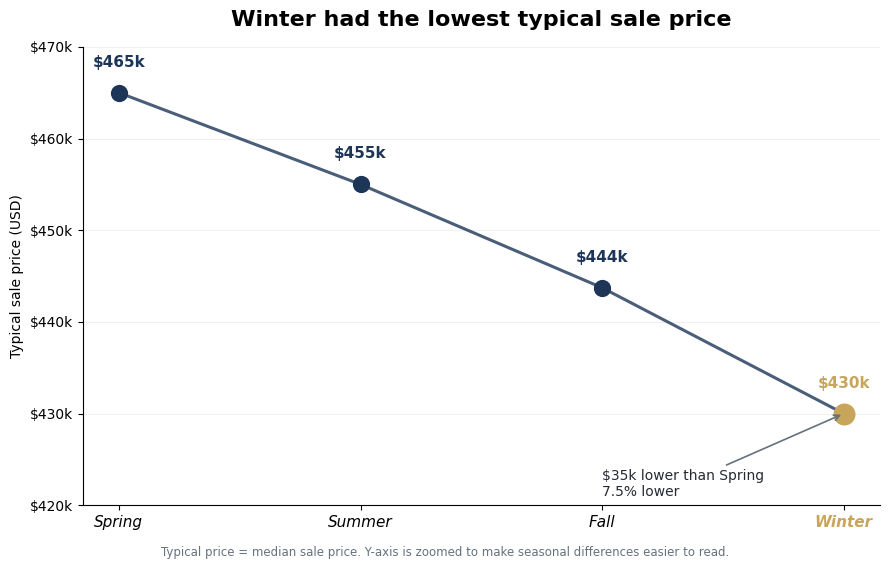

In [19]:
# Create a cleaner H1 chart using dots connected by a line.
# This chart shows the typical sale price across seasons.
#
# Why this version:
# - easier for non-technical people to read
# - cleaner than the lollipop chart
# - avoids the visual feel of "bars with a truncated axis"
# - Winter is highlighted because it has the lowest typical sale price
#
# Note:
# "Typical price" here means median sale price.

import matplotlib.pyplot as plt

season_order = ["Spring", "Summer", "Fall", "Winter"]
season_plot = season_final.loc[season_order].copy()

# Prepare x and y values
x = range(len(season_order))
y = season_plot["median_price"].values

# Colors
navy = "#1D3557"
gold = "#C7A55B"
grey = "#66717E"

fig, ax = plt.subplots(figsize=(9, 5.5))

# Draw connecting line
ax.plot(
    x, y,
    linewidth=2.2,
    color=navy,
    alpha=0.8
)

# Draw dots
for i, season in enumerate(season_order):
    price = season_plot.loc[season, "median_price"]
    color = gold if season == "Winter" else navy
    size = 220 if season == "Winter" else 130

    ax.scatter(
        i, price,
        s=size,
        color=color,
        zorder=3
    )

# Add value labels above dots
for i, season in enumerate(season_order):
    price = season_plot.loc[season, "median_price"]
    color = gold if season == "Winter" else navy

    ax.text(
        i,
        price + 2500,
        f"${price/1000:.0f}k",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=color
    )

# Add annotation for Winter vs Spring
spring_price = season_plot.loc["Spring", "median_price"]
winter_price = season_plot.loc["Winter", "median_price"]

winter_saving_usd = spring_price - winter_price
winter_saving_pct = (winter_saving_usd / spring_price) * 100

ax.annotate(
    f"${winter_saving_usd/1000:.0f}k lower than Spring\n{winter_saving_pct:.1f}% lower",
    xy=(3, winter_price),
    xytext=(2.0, 421000),
    arrowprops=dict(
        arrowstyle="->",
        color=grey,
        linewidth=1.2
    ),
    fontsize=10,
    color="#252B33"
)

# Title and labels
ax.set_title(
    "Winter had the lowest typical sale price",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Typical sale price (USD)")
ax.set_xlabel("")

# Set x-axis labels
ax.set_xticks(list(x))
ax.set_xticklabels(season_order)

# Italicize all season labels and highlight Winter
for label in ax.get_xticklabels():
    label.set_fontstyle("italic")
    label.set_fontsize(11)

    if label.get_text() == "Winter":
        label.set_color(gold)
        label.set_fontweight("bold")

# Keep y-axis zoomed for readability
ax.set_ylim(420000, 470000)

# Format y-axis ticks
ax.set_yticks([420000, 430000, 440000, 450000, 460000, 470000])
ax.set_yticklabels(["$420k", "$430k", "$440k", "$450k", "$460k", "$470k"])

# Clean up chart style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

# Add note for clarity
fig.text(
    0.5,
    -0.02,
    "Typical price = median sale price. Y-axis is zoomed to make seasonal differences easier to read.",
    ha="center",
    fontsize=8.5,
    color=grey
)

plt.tight_layout()
plt.show()

### H1 finding

Winter has the lowest median sale price at about **$430,000**, compared with about **$465,000 in spring**.

That is approximately **$35,000 / 7.5% lower**.

**Interpretation:** Winter may offer better prices if Nicole's timing is flexible, but fewer homes are sold in winter.

**Limitation:** The dataset covers only about one year.

## 7. Distance-based market summary

For H2, H3, and the combined trade-off analysis, use homes within Nicole's middle-price range and compare the same fixed distance bands.

In [20]:
all_distance_summary = (
    middle_price_df.groupby("distance_band", observed=True)
    .agg(
        median_price_usd=("price", "median"),
        median_space_sqft=("sqft_living", "median"),
        population_density_people_per_km2=("population_density", "median"),
        number_of_sales=("price", "size")
    )
    .reindex(distance_labels)
)

central_price = all_distance_summary.loc["0–5 km", "median_price_usd"]
central_space = all_distance_summary.loc["0–5 km", "median_space_sqft"]

all_distance_summary["price_saving_usd"] = central_price - all_distance_summary["median_price_usd"]
all_distance_summary["price_saving_pct"] = all_distance_summary["price_saving_usd"] / central_price * 100
all_distance_summary["extra_space_sqft"] = all_distance_summary["median_space_sqft"] - central_space
all_distance_summary["extra_space_pct"] = all_distance_summary["extra_space_sqft"] / central_space * 100

all_distance_summary.round(1)

,median_price_usd,median_space_sqft,population_density_people_per_km2,number_of_sales,price_saving_usd,price_saving_pct,extra_space_sqft,extra_space_pct
distance_band,,,,,,,,
0–5 km,498000.0,1450.0,3787.9,613,0.0,0.0,0.0,0.0
5–10 km,475000.0,1460.0,2938.1,2488,23000.0,4.6,10.0,0.7
10–15 km,446450.0,1720.0,2218.7,1811,51550.0,10.4,270.0,18.6
15–20 km,447000.0,1970.0,1492.1,2265,51000.0,10.2,520.0,35.9
20–30 km,460000.0,2130.0,906.3,2103,38000.0,7.6,680.0,46.9
30–50 km,415000.0,2420.0,199.6,1504,83000.0,16.7,970.0,66.9
50+ km,369500.0,2260.0,20.5,48,128500.0,25.8,810.0,55.9


## 8. H2 — Centrality

### Question
How does typical price change as distance from central Seattle increases?

The comparison uses homes within the middle-price range so the distance bands represent a comparable market segment.

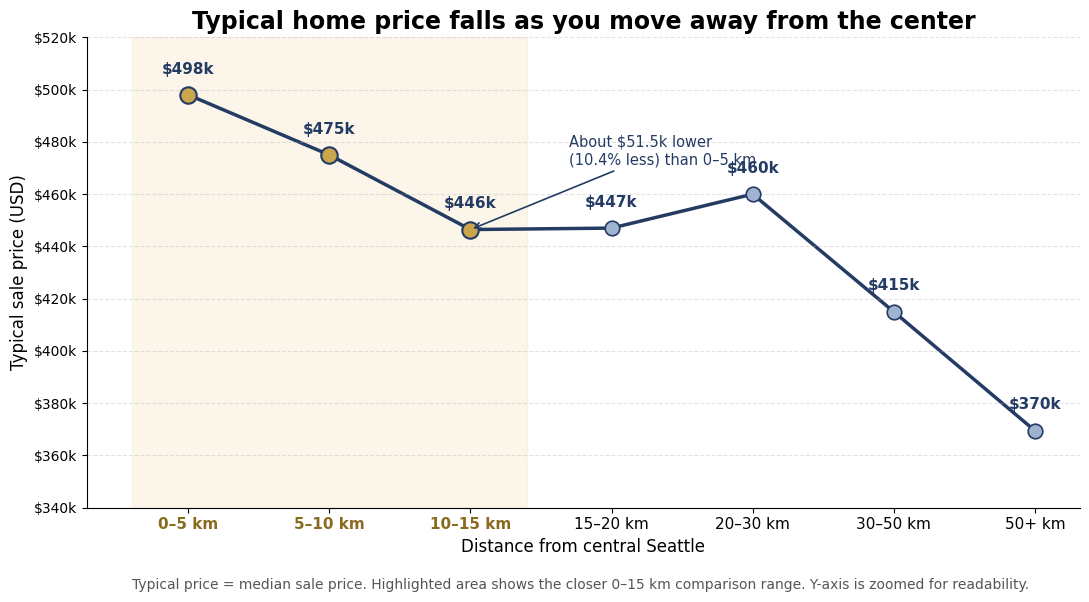

In [21]:
# Create a presentation-friendly H2 chart:
# "Typical home prices generally fall as distance from central Seattle increases."
# This chart:
# - uses all distance bands
# - highlights the closer 0–15 km comparison range
# - shows the typical sale price in each band
# - annotates the key comparison: 10–15 km vs 0–5 km

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Prepare data for plotting
h2_plot = all_distance_summary.reset_index().copy()

# Keep the bands in the intended order
band_order = ["0–5 km", "5–10 km", "10–15 km", "15–20 km", "20–30 km", "30–50 km", "50+ km"]
h2_plot["distance_band"] = pd.Categorical(h2_plot["distance_band"], categories=band_order, ordered=True)
h2_plot = h2_plot.sort_values("distance_band").reset_index(drop=True)

# Create x and y values
x = list(range(len(h2_plot)))
y = h2_plot["median_price_usd"]

# Create figure
fig, ax = plt.subplots(figsize=(11, 6))

# Light highlight for the closer 0–15 km comparison range
ax.axvspan(-0.4, 2.4, color="#F4E7C1", alpha=0.35)

# Main line across all distance bands
ax.plot(x, y, color="#243B63", linewidth=2.5, zorder=1)

# Highlight the closer comparison bands
ax.scatter(x[:3], y[:3], s=140, color="#C9A54C", edgecolor="#243B63", linewidth=1.5, zorder=3)

# Show farther bands in a softer color
ax.scatter(x[3:], y[3:], s=110, color="#9FB3D1", edgecolor="#243B63", linewidth=1.2, zorder=3)

# Add value labels above each point
for i, value in enumerate(y):
    ax.text(
        x[i],
        value + 7000,
        f"${value/1000:.0f}k",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#243B63"
    )

# Annotate the key trade-off: 10–15 km vs 0–5 km
save_usd = h2_plot.loc[2, "price_saving_usd"]
save_pct = h2_plot.loc[2, "price_saving_pct"]

ax.annotate(
    f"About ${save_usd/1000:.1f}k lower\n({save_pct:.1f}% less) than 0–5 km",
    xy=(2, y.iloc[2]),
    xytext=(2.7, y.iloc[2] + 25000),
    arrowprops=dict(arrowstyle="->", color="#243B63", lw=1.2),
    fontsize=10.5,
    color="#243B63",
    ha="left"
)

# Titles and labels
ax.set_title("Typical home price falls as you move away from the center", fontsize=17, fontweight="bold")
ax.set_xlabel("Distance from central Seattle", fontsize=12)
ax.set_ylabel("Typical sale price (USD)", fontsize=12)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(h2_plot["distance_band"], fontsize=11)

# Make the first three tick labels stand out
for i, label in enumerate(ax.get_xticklabels()):
    if i < 3:
        label.set_fontweight("bold")
        label.set_color("#8A6A1F")

# Format y-axis as currency
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"${val/1000:.0f}k"))

# Zoom the y-axis for readability
ax.set_ylim(340000, 520000)

# Grid and styling
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add note below chart
fig.text(
    0.125,
    0.01,
    "Typical price = median sale price. Highlighted area shows the closer 0–15 km comparison range. Y-axis is zoomed for readability.",
    fontsize=10,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### H2 finding

- **0–5 km:** median price ≈ **$498,000**
- **10–15 km:** median price ≈ **$446,450**

The 10–15 km band is about **$51,550 / 10.4% cheaper** than 0–5 km.

**Interpretation:** Central homes carry a price premium. Looking slightly farther out may reduce that premium while keeping Nicole relatively close to central Seattle.

The pattern is not perfectly linear across every distance band.

## 9. H3 — Living space

### Question
Within the middle-price range, does moving farther from central Seattle provide more living space?

Using the same price segment prevents the comparison from simply reflecting different parts of the market.

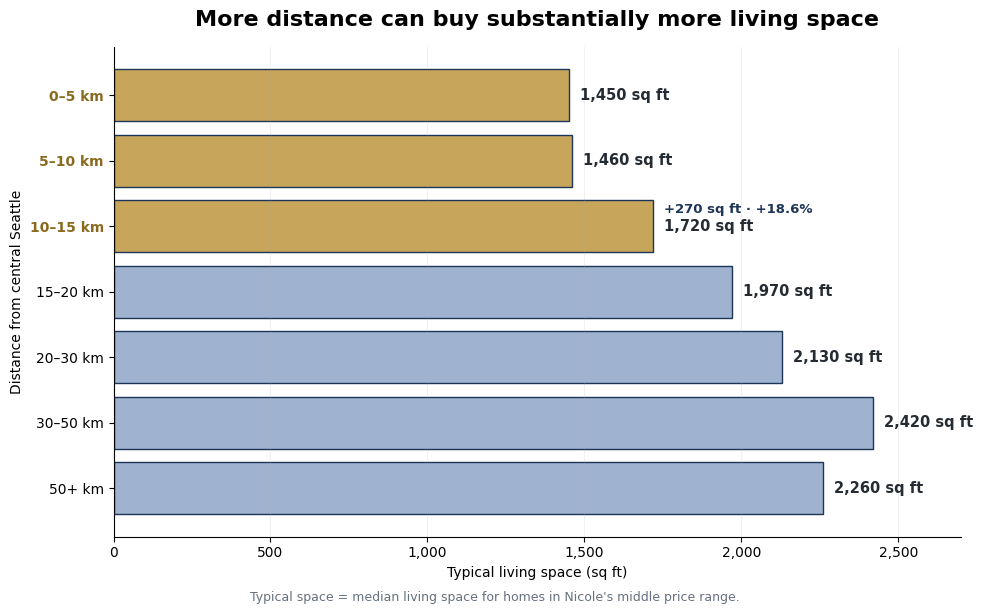

In [22]:
# Create the final H3 chart showing typical living space by distance band.
#
# This chart:
# - shows ALL distance bands for full market context
# - highlights the closer 0–15 km bands for comparison
# - uses a true zero baseline because bar length represents living space
# - directly labels the typical square footage
# - highlights the +270 sq ft / +18.6% difference between 0–5 km and 10–15 km
#
# "Typical space" means median living space within Nicole's middle price range.

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Prepare the data in distance order.
h3_plot = all_distance_summary.reset_index().copy()

band_order = [
    "0–5 km",
    "5–10 km",
    "10–15 km",
    "15–20 km",
    "20–30 km",
    "30–50 km",
    "50+ km"
]

h3_plot["distance_band"] = pd.Categorical(
    h3_plot["distance_band"],
    categories=band_order,
    ordered=True
)

h3_plot = (
    h3_plot
    .sort_values("distance_band")
    .reset_index(drop=True)
)

# Presentation colors.
navy = "#1D3557"
gold = "#C7A55B"
steel = "#9FB3D1"
charcoal = "#252B33"

# Highlight the first three distance bands.
bar_colors = [
    gold,   # 0–5 km
    gold,   # 5–10 km
    gold,   # 10–15 km
    steel,  # 15–20 km
    steel,  # 20–30 km
    steel,  # 30–50 km
    steel   # 50+ km
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    h3_plot["distance_band"],
    h3_plot["median_space_sqft"],
    color=bar_colors,
    edgecolor=navy,
    linewidth=1
)

# Add direct square-foot labels.
for bar, value in zip(bars, h3_plot["median_space_sqft"]):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f} sq ft",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color=charcoal
    )

# Highlight the 10–15 km gain compared with the 0–5 km baseline.
space_gain = h3_plot.loc[2, "extra_space_sqft"]
space_gain_pct = h3_plot.loc[2, "extra_space_pct"]

ax.text(
    h3_plot.loc[2, "median_space_sqft"] + 35,
    2 - 0.20,
    f"+{space_gain:,.0f} sq ft · +{space_gain_pct:.1f}%",
    fontsize=9.5,
    color=navy,
    fontweight="bold"
)

# Presentation-friendly title and axes.
ax.set_title(
    "More distance can buy substantially more living space",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Typical living space (sq ft)")
ax.set_ylabel("Distance from central Seattle")

# Bars should start at zero because their length represents magnitude.
ax.set_xlim(0, 2700)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, pos: f"{value:,.0f}")
)

# Put closest distance at the top.
ax.invert_yaxis()

# Style first three labels to match the highlighted bars.
for i, label in enumerate(ax.get_yticklabels()):
    if i < 3:
        label.set_fontweight("bold")
        label.set_color("#8A6A1F")

# Clean styling.
ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Methodology note.
fig.text(
    0.5,
    -0.01,
    "Typical space = median living space for homes in Nicole's middle price range.",
    ha="center",
    fontsize=9,
    color="#66717E"
)

plt.tight_layout()
plt.show()

### H3 finding

- **0–5 km:** median living space ≈ **1,450 sq ft**
- **10–15 km:** median living space ≈ **1,720 sq ft**

That is about **270 sq ft / 18.6% more space** at 10–15 km.

**Interpretation:** Moving slightly farther out can provide noticeably more living space within the same market segment.

## 10. Trade-off analysis

Price and living space improve as distance increases, but population density generally falls.

To compare the three measures on the same scale, express each one as a percentage change from the **0–5 km baseline**.

In [23]:
# Build a summary trade-off chart for Nicole's key features.
# The chart compares all distance bands against the 0–5 km baseline.
#
# It shows:
# - price change (%) -> below 0 means cheaper
# - space change (%) -> above 0 means more living space
# - density change (%) -> below 0 means less dense / less urban
#
# This is useful for the final recommendation slide because it shows
# the main trade-off in one place.

summary_tradeoff = all_distance_summary.reset_index().copy()

# Rename the distance column clearly in case it comes from the index
summary_tradeoff = summary_tradeoff.rename(columns={"index": "distance_band"})

# Use the first row (0–5 km) as the baseline
baseline_price = summary_tradeoff.loc[0, "median_price_usd"]
baseline_space = summary_tradeoff.loc[0, "median_space_sqft"]
baseline_density = summary_tradeoff.loc[0, "population_density_people_per_km2"]

# Calculate percentage change vs the 0–5 km band
summary_tradeoff["price_change_pct"] = (
    (summary_tradeoff["median_price_usd"] - baseline_price)
    / baseline_price
    * 100
)

summary_tradeoff["space_change_pct"] = (
    (summary_tradeoff["median_space_sqft"] - baseline_space)
    / baseline_space
    * 100
)

summary_tradeoff["density_change_pct"] = (
    (summary_tradeoff["population_density_people_per_km2"] - baseline_density)
    / baseline_density
    * 100
)

summary_tradeoff

,distance_band,median_price_usd,median_space_sqft,population_density_people_per_km2,number_of_sales,price_saving_usd,price_saving_pct,extra_space_sqft,extra_space_pct,price_change_pct,space_change_pct,density_change_pct
0,0–5 km,498000.0,1450.0,3787.945993,613,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,5–10 km,475000.0,1460.0,2938.081804,2488,23000.0,4.618474,10.0,0.689655,-4.618474,0.689655,-22.436017
2,10–15 km,446450.0,1720.0,2218.706526,1811,51550.0,10.351406,270.0,18.620690,-10.351406,18.620690,-41.427187
3,15–20 km,447000.0,1970.0,1492.051115,2265,51000.0,10.240964,520.0,35.862069,-10.240964,35.862069,-60.610549
4,20–30 km,460000.0,2130.0,906.268557,2103,38000.0,7.630522,680.0,46.896552,-7.630522,46.896552,-76.074935
5,30–50 km,415000.0,2420.0,199.557957,1504,83000.0,16.666667,970.0,66.896552,-16.666667,66.896552,-94.731763
6,50+ km,369500.0,2260.0,20.513793,48,128500.0,25.803213,810.0,55.862069,-25.803213,55.862069,-99.458445


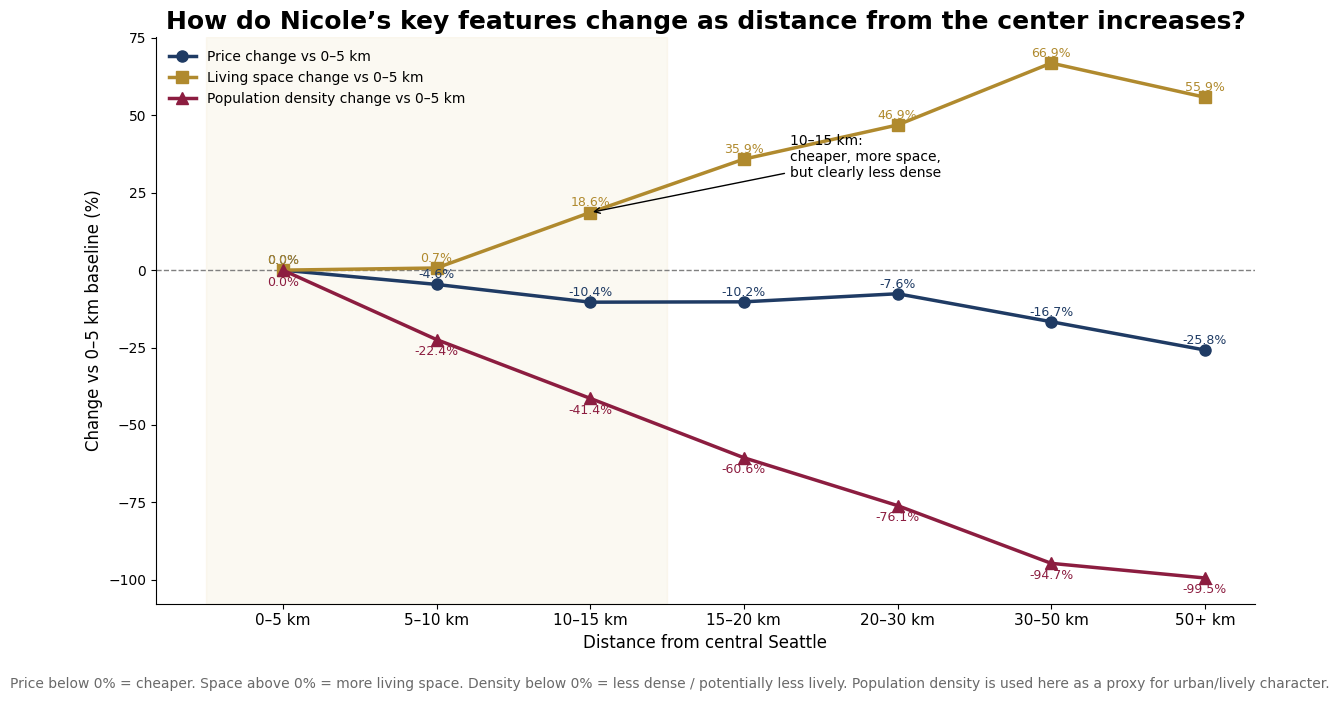

In [24]:
# Create a single summary chart that combines Nicole's key trade-offs.
# Highlight the closer 0–15 km range to make the central-to-inner-market trade-off easier to compare.

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(summary_tradeoff))
labels = summary_tradeoff["distance_band"]

price_color = "#1f3b64"    # navy
space_color = "#b08a2e"    # muted gold
density_color = "#8C1D40"  # slate blue-grey

plt.figure(figsize=(12, 7))

# Highlight the closer comparison range
plt.axvspan(-0.5, 2.5, color="#d8b365", alpha=0.08)

# Zero line
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Plot the three trade-off lines
plt.plot(
    x,
    summary_tradeoff["price_change_pct"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=price_color,
    label="Price change vs 0–5 km"
)

plt.plot(
    x,
    summary_tradeoff["space_change_pct"],
    marker="s",
    linewidth=2.5,
    markersize=8,
    color=space_color,
    label="Living space change vs 0–5 km"
)

plt.plot(
    x,
    summary_tradeoff["density_change_pct"],
    marker="^",
    linewidth=2.5,
    markersize=8,
    color=density_color,
    label="Population density change vs 0–5 km"
)

# Add value labels for each point
for i, value in enumerate(summary_tradeoff["price_change_pct"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center", fontsize=9, color=price_color)

for i, value in enumerate(summary_tradeoff["space_change_pct"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center", fontsize=9, color=space_color)

for i, value in enumerate(summary_tradeoff["density_change_pct"]):
    plt.text(i, value - 5, f"{value:.1f}%", ha="center", fontsize=9, color=density_color)

# Optional: call out the 10–15 km band because it is an important trade-off point
plt.annotate(
    "10–15 km:\ncheaper, more space,\nbut clearly less dense",
    xy=(2, summary_tradeoff.loc[2, "space_change_pct"]),
    xytext=(3.3, 30),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.xticks(x, labels, fontsize=11)
plt.ylabel("Change vs 0–5 km baseline (%)", fontsize=12)
plt.xlabel("Distance from central Seattle", fontsize=12)

plt.title(
    "How do Nicole’s key features change as distance from the center increases?",
    fontsize=18,
    weight="bold"
)

plt.legend(frameon=False, loc="best")

plt.figtext(
    0.5,
    0.01,
    "Price below 0% = cheaper. Space above 0% = more living space. "
    "Density below 0% = less dense / potentially less lively. "
    "Population density is used here as a proxy for urban/lively character.",
    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Trade-off finding

At **10–15 km**, compared with 0–5 km:

- typical price is about **10.4% lower**
- typical living space is about **18.6% higher**
- population density is about **41% lower**

This makes 10–15 km a **strong practical compromise**, not a mathematically optimal location.

Population density remains only a proxy for urban character.

## 11. ZIP-code screening and shortlist

The distance analysis suggests the closer **0–15 km range** is useful for a practical first screening.

This is an **analytical screening range derived from the trade-off analysis**, not a location limit originally specified by Nicole.

Within that range, compare ZIP codes using price, living space, population density, distance, and number of suitable sales.

In [25]:
screening_df = df[
    df["price"].between(lower_price, upper_price)
    & (df["distance_km"] <= 15)
].copy()

zip_summary = (
    screening_df.groupby("zipcode")
    .agg(
        median_distance_km=("distance_km", "median"),
        population_density=("population_density", "first"),
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        suitable_sales=("price", "size")
    )
    .reset_index()
)

zip_summary.head()

,zipcode,median_distance_km,population_density,median_price,median_space,suitable_sales
0,98004,10.364937,1779.853135,617500.0,1605.0,16
1,98005,12.202680,913.105873,554000.0,1760.0,45
2,98006,13.580645,1352.778675,515000.0,1920.0,118
3,98007,14.393204,2314.184686,499990.0,1730.0,91
4,98008,14.919052,1728.677347,520000.0,1680.0,3


### 11.1 Reliability filter

Exclude ZIP codes with fewer than **30 suitable sales**.

This is a practical reliability filter, not a statistical-significance threshold.

In [26]:
reliable_zips = zip_summary[zip_summary["suitable_sales"] >= 30].copy()

typical_density = reliable_zips["population_density"].median()
typical_price = reliable_zips["median_price"].median()
typical_space = reliable_zips["median_space"].median()
typical_distance = reliable_zips["median_distance_km"].median()

print("Reliable ZIP codes:", len(reliable_zips))
print("Typical population density:", round(typical_density), "people/km²")
print("Typical median price: $", round(typical_price))
print("Typical living space:", round(typical_space), "sq ft")
print("Typical distance:", round(typical_distance, 1), "km")

Reliable ZIP codes: 30
Typical population density: 2652 people/km²
Typical median price: $ 490000
Typical living space: 1508 sq ft
Typical distance: 8.6 km


### 11.2 Balanced screening criteria

Among reliable ZIP codes, keep candidates with:

- population density **at or above** the typical reliable ZIP
- median price **at or below** the typical reliable ZIP
- median living space **at or above** the typical reliable ZIP

These are screening rules, not a universal definition of a good neighbourhood.

In [27]:
balanced_candidates = reliable_zips[
    (reliable_zips["population_density"] >= typical_density)
    & (reliable_zips["median_price"] <= typical_price)
    & (reliable_zips["median_space"] >= typical_space)
].copy()

candidate_comparison = balanced_candidates[
    ["zipcode", "median_distance_km", "population_density", "median_price", "median_space", "suitable_sales"]
].copy()

candidate_comparison["price_vs_typical"] = candidate_comparison["median_price"] - typical_price
candidate_comparison["space_vs_typical"] = candidate_comparison["median_space"] - typical_space
candidate_comparison["density_vs_typical_pct"] = (
    (candidate_comparison["population_density"] - typical_density)
    / typical_density * 100
)

candidate_comparison.sort_values("median_price")

,zipcode,median_distance_km,population_density,median_price,median_space,suitable_sales,price_vs_typical,space_vs_typical,density_vs_typical_pct
22,98118,7.904852,2770.698628,420000.0,1740.0,271,-70000.0,232.5,4.459069
26,98126,7.934317,2870.003620,420000.0,1560.0,230,-70000.0,52.5,8.203001
25,98125,12.045907,2811.709645,427250.0,1595.0,308,-62750.0,87.5,6.005240


### 11.3 Shortlist

The screening process leaves three ZIP codes:

- **98118** — most living space among the three
- **98126** — highest population density among the three
- **98125** — most suitable sales among the three

This is a **shortlist for further investigation**, not a final ranking.

In [28]:
shortlisted_zipcodes = ["98118", "98126", "98125"]

shortlisted_homes = screening_df[
    screening_df["zipcode"].isin(shortlisted_zipcodes)
].copy()

zip_map_points = (
    shortlisted_homes.groupby("zipcode")
    .agg(
        median_lat=("lat", "median"),
        median_long=("long", "median"),
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        median_distance_km=("distance_km", "median"),
        suitable_sales=("price", "size")
    )
    .reset_index()
)

map_summary = zip_map_points.merge(
    zip_summary[["zipcode", "population_density"]],
    on="zipcode",
    how="left"
)

map_summary

,zipcode,median_lat,median_long,median_price,median_space,median_distance_km,suitable_sales,population_density
0,98118,47.55030,-122.276,420000.0,1740.0,7.904852,271,2770.698628
1,98125,47.71635,-122.304,427250.0,1595.0,12.045907,308,2811.709645
2,98126,47.54535,-122.376,420000.0,1560.0,7.934317,230,2870.003620


In [30]:
# Create a presentation-friendly version of the shortlist map.
# The ZIP codes are written directly beside the points so the audience
# can understand the map even when it is used as a static screenshot.
# Central Seattle is included as a reference point.

seattle_reference = pd.DataFrame({
    "zipcode": ["Central Seattle"],
    "median_lat": [47.61],
    "median_long": [-122.33],
    "median_price": [None],
    "median_space": [None],
    "median_distance_km": [0],
    "population_density": [None],
    "suitable_sales": [120]
})

map_with_center = pd.concat(
    [map_summary, seattle_reference],
    ignore_index=True
)

fig = px.scatter_map(
    map_with_center,
    lat="median_lat",
    lon="median_long",
    text="zipcode",
    hover_name="zipcode",
    hover_data={
        "median_price": ":$,.0f",
        "median_space": ":,.0f",
        "median_distance_km": ":.1f",
        "population_density": ":,.0f",
        "suitable_sales": True,
        "median_lat": False,
        "median_long": False
    },
    size="suitable_sales",
    zoom=10,
    height=650
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    map_style="open-street-map",
    title="Shortlisted areas for Nicole"
)

fig.show()

## 12. Recommendations

### Where to start
Begin with **98118, 98126, and 98125** as practical areas for further investigation.

### When to buy
If timing is flexible, **winter** deserves attention because it had the lowest median price in this dataset. The trade-off is fewer available sales.

### What to adjust
Be flexible about exact centrality. Moving slightly farther out can reduce price and increase living space.

### Property-level filters to decide next
Before choosing individual homes, Nicole should define preferences such as minimum living space, grade/condition, property age, bedrooms/bathrooms, and desired features.

These are future client decisions, not assumptions made in this analysis.

## 13. Limitations and next steps

### Limitations
1. **Historical data** — sales are from 2014–2015.
2. **One-year view** — seasonal patterns should not be treated as long-term rules.
3. **Straight-line distance** — geographic distance is not commute time.
4. **Density proxy** — population density does not directly measure liveliness or neighbourhood quality.
5. **Shortlist, not final ranking** — the screening narrows the market but does not prove one ZIP code is objectively best.

### Next steps
Add:
- current listings and prices
- travel time and public transport
- amenities and neighbourhood activity
- safety / schools where relevant
- Nicole's final property-level preferences

**Conclusion:** Use the EDA to narrow the search, then validate the shortlist with current data and real listings.